In [13]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [59]:
data=pd.read_csv('datasets/iris.csv',header=None)
e=LabelEncoder()
data[4]=e.fit_transform(data[4])
data.drop(columns=[2,3],inplace=True)
data=data[data[4]!=0]
x=data.iloc[:,:2]
y=data.iloc[:,2]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
data

,0,1,4
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1
...,...,...,...
145,6.7,3.0,2
146,6.3,2.5,2
147,6.5,3.0,2
148,6.2,3.4,2


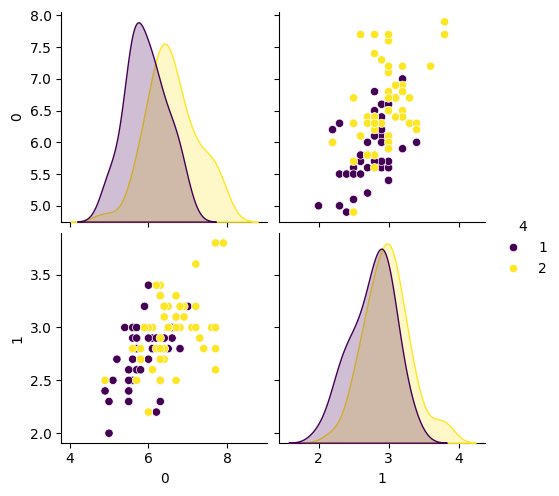

In [60]:
sns.pairplot(data,hue=4,palette='viridis',)

In [62]:
m1=DecisionTreeClassifier()
m1.fit(x_train,y_train)

DecisionTreeClassifier()

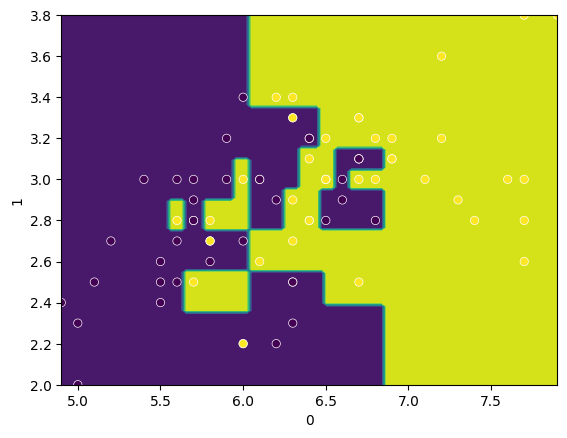

In [85]:
xx1=np.linspace(x[0].min(),x[0].max(),100)
xx2=np.linspace(x[1].min(),x[1].max(),100)
X=np.meshgrid(xx1,xx2)
xx1=X[0]
xx2=X[1]
Y=m1.predict(np.c_[xx1.ravel(),xx2.ravel()]).reshape(xx1.shape)

plt.contourf(xx1,xx2,Y)
sns.scatterplot(x=x_train[0],y=x_train[1],c=y_train)
plt.show()

In [86]:
m2=RandomForestClassifier(n_estimators=100)
m2.fit(x_train,y_train)

RandomForestClassifier()

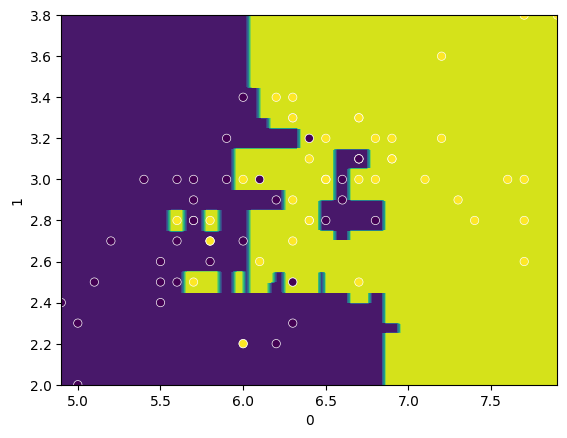

In [88]:
xx1=np.linspace(x[0].min(),x[0].max(),100)
xx2=np.linspace(x[1].min(),x[1].max(),500)
X=np.meshgrid(xx1,xx2)
xx1=X[0]
xx2=X[1]
Y=m2.predict(np.c_[xx1.ravel(),xx2.ravel()]).reshape(xx1.shape)

plt.contourf(xx1,xx2,Y)
sns.scatterplot(x=x_train[0],y=x_train[1],c=y_train)
plt.show()

In [1]:
from sklearn.datasets import make_circles

In [43]:
data=make_circles(n_samples=500,noise=0.25,factor=0.5,random_state=2)
x=data[0]
y=data[1]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
x,y

(array([[-0.76522208, -0.0784542 ],
        [ 0.58130898, -0.01143267],
        [ 0.53890812, -0.55952238],
        [-0.79695474, -0.12970808],
        [ 0.72853835, -0.64178677],
        [-0.01400586, -0.17495052],
        [ 1.17678313, -0.29517875],
        [-0.17366748, -0.64314673],
        [-0.33136498,  0.54504064],
        [ 0.31753688,  0.37600575],
        [ 0.39166819, -0.51515618],
        [-0.1330722 ,  0.92937972],
        [-0.71497124, -0.65385817],
        [-0.90769585, -0.61736826],
        [-0.35242255,  0.30229255],
        [ 0.41419349, -0.84250646],
        [-0.38661511,  0.5618579 ],
        [ 0.18895599, -0.7077653 ],
        [ 0.37286841,  0.39917174],
        [-0.36329679, -1.38795986],
        [ 0.66288519, -0.33942797],
        [-0.63422181,  0.80883085],
        [ 0.36227206, -0.00810023],
        [-0.48445898, -0.02558282],
        [ 0.0185841 ,  1.45369704],
        [-0.56834529, -1.30021847],
        [ 0.94394132,  0.28158335],
        [-0.43264046,  0.229

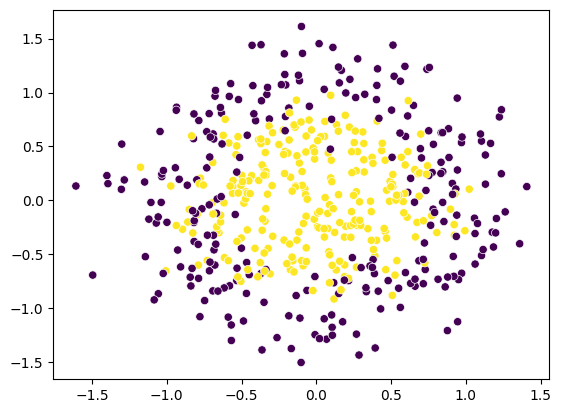

In [32]:
sns.scatterplot(x=data[0].T[0],y=data[0].T[1],c=data[1])
plt.show()

In [34]:
m1=DecisionTreeClassifier(random_state=2)
m1.fit(x_train,y_train)
accuracy_score(y_test,m1.predict(x_test))

0.73

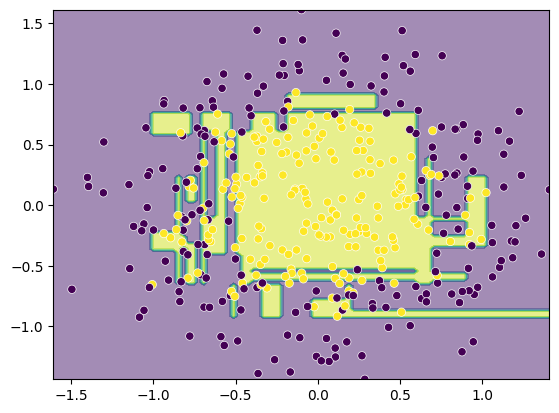

In [62]:
xx1=np.linspace(x_train.T[0].min(),x_train.T[0].max(),100)
xx2=np.linspace(x_train.T[1].min(),x_train.T[1].max(),100)
X=np.meshgrid(xx1,xx2)
Y=m1.predict(np.c_[X[0].ravel(),X[1].ravel()]).reshape(X[0].shape)
plt.contourf(X[0],X[1],Y,alpha=0.5)
sns.scatterplot(x=x_train.T[0],y=x_train.T[1],c=y_train)
plt.show()

In [84]:
m2=RandomForestClassifier(n_estimators=100,random_state=2,min_samples_split=5,min_samples_leaf=3)
# see more hyperparameters in official website
m2.fit(x_train,y_train)
accuracy_score(y_test,m2.predict(x_test))

0.82

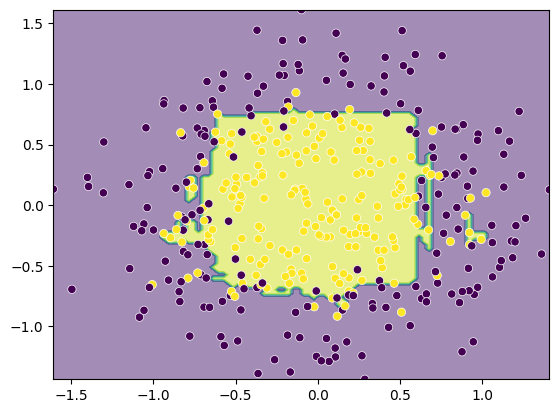

In [85]:
xx1=np.linspace(x_train.T[0].min(),x_train.T[0].max(),100)
xx2=np.linspace(x_train.T[1].min(),x_train.T[1].max(),100)
X=np.meshgrid(xx1,xx2)
Y=m2.predict(np.c_[X[0].ravel(),X[1].ravel()]).reshape(X[0].shape)
plt.contourf(X[0],X[1],Y,alpha=0.5)
sns.scatterplot(x=x_train.T[0],y=x_train.T[1],c=y_train)
plt.show()